In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve,auc)

In [8]:
data = load_breast_cancer()
X=data.data
y=data.target
print("Dataset Shape:",X.shape)
print("Classes:",np.unique(y))


Dataset Shape: (569, 30)
Classes: [0 1]


In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [77]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [78]:
mle_model = LogisticRegression(penalty=None,max_iter=5000,random_state=42)
mle_model.fit(X_train,y_train)
y_pred_mle = mle_model.predict(X_test)

In [79]:
map_l2 = LogisticRegression(penalty='l2',C=1.0,solver='lbfgs',max_iter=5000,random_state=42)
map_l2.fit(X_train,y_train)
y_pred_l2  = map_l2.predict(X_test)


In [80]:
map_l1 = LogisticRegression(penalty='l1',solver='liblinear',C=1.0,max_iter=5000,random_state=42)
map_l1.fit(X_train,y_train)
y_pred_l1  = map_l1.predict(X_test)


In [81]:
def evaluate(model_name,y_true,y_pred):
    print("\n", "="*40)
    print(model_name)
    print("="*40)

    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision :",precision_score(y_true,y_pred))
    print("Recall:",recall_score(y_true,y_pred))
    print("F1 score :",f1_score(y_true,y_pred))
    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))


In [82]:
evaluate("MLE",y_test,y_pred_mle)
evaluate("MAP (L2)",y_test,y_pred_l2)
evaluate("MAP (L1)",y_test,y_pred_l1)





MLE
Accuracy : 0.9210526315789473
Precision : 0.9701492537313433
Recall: 0.9027777777777778
F1 score : 0.935251798561151

Confusion Matrix
[[40  2]
 [ 7 65]]

MAP (L2)
Accuracy : 0.9824561403508771
Precision : 0.9861111111111112
Recall: 0.9861111111111112
F1 score : 0.9861111111111112

Confusion Matrix
[[41  1]
 [ 1 71]]

MAP (L1)
Accuracy : 0.9912280701754386
Precision : 0.9863013698630136
Recall: 1.0
F1 score : 0.993103448275862

Confusion Matrix
[[41  1]
 [ 0 72]]


In [73]:
print("Number of Zero Coefficients")
print("MLE     :",np.sum(mle_model.coef_[0] == 0))
print("MAP L2  :",np.sum(map_l2.coef_[0] == 0))
print("MAP L1  :",np.sum(map_l1.coef_[0] == 0))

Number of Zero Coefficients
MLE     : 0
MAP L2  : 0
MAP L1  : 14


In [84]:
results= pd.DataFrame(columns=["Model","Accuracy","Precision","Recall","F1 Score"])
models= [
    ("MLE",mle_model,y_pred_mle),
    ("MAP L2",map_l2,y_pred_l2),
    ("MAP L1",map_l1,y_pred_l1)
]
for name,model,pred in models:
    results.loc[len(results)]=[name,accuracy_score(y_test,pred), precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred)]
print(results)
                    

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


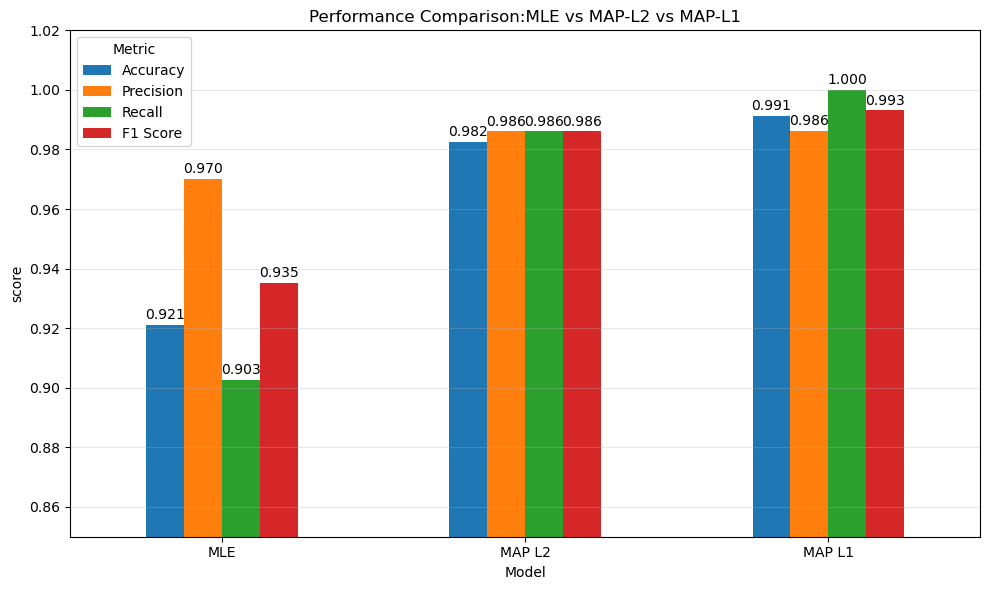

In [90]:
ax=results.set_index("Model").plot(kind="bar",figsize=(10,6))
plt.title("Performance Comparison:MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("score")
plt.ylim(0.85,1.02)
plt.xticks(rotation = 0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)
for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

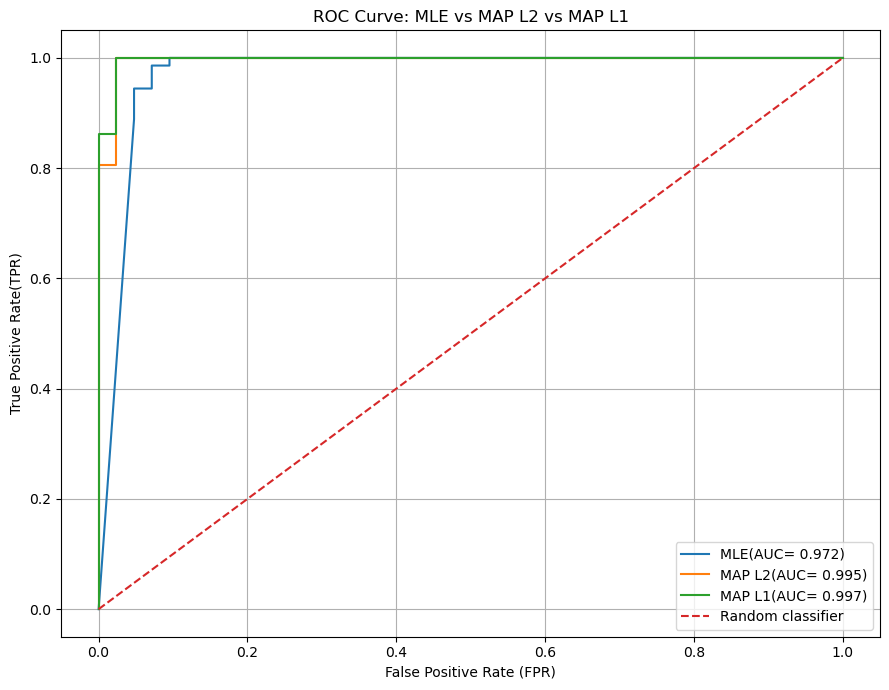

In [96]:
plt.figure(figsize=(9,7))
for name,model,pred in models:
    y_prob=model.predict_proba(X_test)[:,1]
    fpr,tpr,thresholds=roc_curve(y_test,y_prob)
    roc_auc = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{name}(AUC= {roc_auc:.3f})")

plt.plot([0,1],[0,1],linestyle="--",label="Random classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate(TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()